In [1]:
import pandas as pd
import os

In [2]:
cwd= os.getcwd()
print(cwd)
BASE_DIR= os.path.join(cwd,"..")

data= os.path.join(BASE_DIR, "data", "concat_for_eda.csv")

/home/hngoc/thesis/microcytic-reduced/notebooks


In [3]:
df= pd.read_csv(data)
# df= pd.read_excel(data)
print(df)
print(df.shape)

      Hb   MCV   Fe  Ferritin  Transferrin  TSAT (%)    CRP Chẩn đoán  \
0     86  76.6  3.1    1062.0        170.0       2.9  174.8  ACD, IDA   
1    114  78.5  2.2     457.0        145.0       8.5   15.3       ACD   
2     84  75.5  2.6     445.3         93.0      46.3  120.1       ACD   
3    115  79.6  1.7    1151.0        125.0       7.6    9.9       ACD   
4     90  57.3  2.9    2009.0        116.0      14.0   62.9       ACD   
..   ...   ...  ...       ...          ...       ...    ...       ...   
270   87  65.7  NaN       NaN          NaN       NaN    NaN       IDA   
271  113  86.5  5.5     381.5          NaN       NaN    7.3       IDA   
272   89  73.3  5.7     111.1          NaN       NaN    0.7       IDA   
273   84  70.1  NaN       NaN          NaN       NaN    NaN       IDA   
274   82  68.1  NaN       NaN          NaN       NaN    NaN       IDA   

     tiensu_ida  tiensu_acd  ...  HbA2  HbF  HbH  HbBart  HbS  HbE  Hb khác  \
0          True        True  ...   NaN  NaN 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Hb           275 non-null    int64  
 1   MCV          274 non-null    float64
 2   Fe           261 non-null    float64
 3   Ferritin     258 non-null    float64
 4   Transferrin  177 non-null    float64
 5   TSAT (%)     189 non-null    float64
 6   CRP          196 non-null    float64
 7   Chẩn đoán    275 non-null    object 
 8   tiensu_ida   275 non-null    bool   
 9   tiensu_acd   275 non-null    bool   
 10  RBC          129 non-null    float64
 11  MCHC         132 non-null    float64
 12  RDW-CV       92 non-null     float64
 13  TIBC         2 non-null      float64
 14  Ret-He       7 non-null      float64
 15  HbA1         90 non-null     float64
 16  HbA2         80 non-null     float64
 17  HbF          1 non-null      float64
 18  HbH          0 non-null      float64
 19  HbBart  

### Descriptive Statistics by Diagnosis Group

In [5]:
df["Chẩn đoán"].unique().tolist()

['ACD, IDA', 'ACD', 'IDA']

In [6]:
labels = ["ACD", "IDA", "ACD, IDA"]
exclude = labels + ["Giới_nữ"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

for label in labels:
    subset = df[df["Chẩn đoán"] == label][numeric_cols]
    n = len(subset)
    print(f"{label} (n={n})")
    print(subset.describe().round(2).to_string())

ACD (n=130)
          CRP      Fe  Ferritin      Hb  Hb khác  HbA1  HbA2  HbBart  HbE  HbF  HbH  HbS   MCHC     MCV   RBC  RDW-CV  Ret-He  TIBC  TSAT (%)  Transferrin
count  130.00  130.00    130.00  130.00      0.0   1.0   1.0     0.0  0.0  0.0  0.0  0.0    1.0  130.00  1.00     1.0     0.0   0.0    130.00       130.00
mean    91.75    3.44    967.64   92.12      NaN  97.6   2.4     NaN  NaN  NaN  NaN  NaN  317.0   73.01  3.77    13.6     NaN   NaN     12.92       149.99
std     88.12    1.05   1121.88   17.88      NaN   NaN   NaN     NaN  NaN  NaN  NaN  NaN    NaN    6.45   NaN     NaN     NaN   NaN     11.80        41.79
min      5.80    1.30    103.00   53.00      NaN  97.6   2.4     NaN  NaN  NaN  NaN  NaN  317.0   56.70  3.77    13.6     NaN   NaN      1.50        58.00
25%     25.22    2.70    350.62   81.25      NaN  97.6   2.4     NaN  NaN  NaN  NaN  NaN  317.0   69.18  3.77    13.6     NaN   NaN      7.22       118.00
50%     63.05    3.40    688.00   90.00      NaN  97.6   2

### Missing Value Rate by Diagnosis Group
Heatmap showing the percentage of missing values for each feature within each diagnosis group. Supports the argument for not imputing — each diagnosis group has a different missing data pattern.

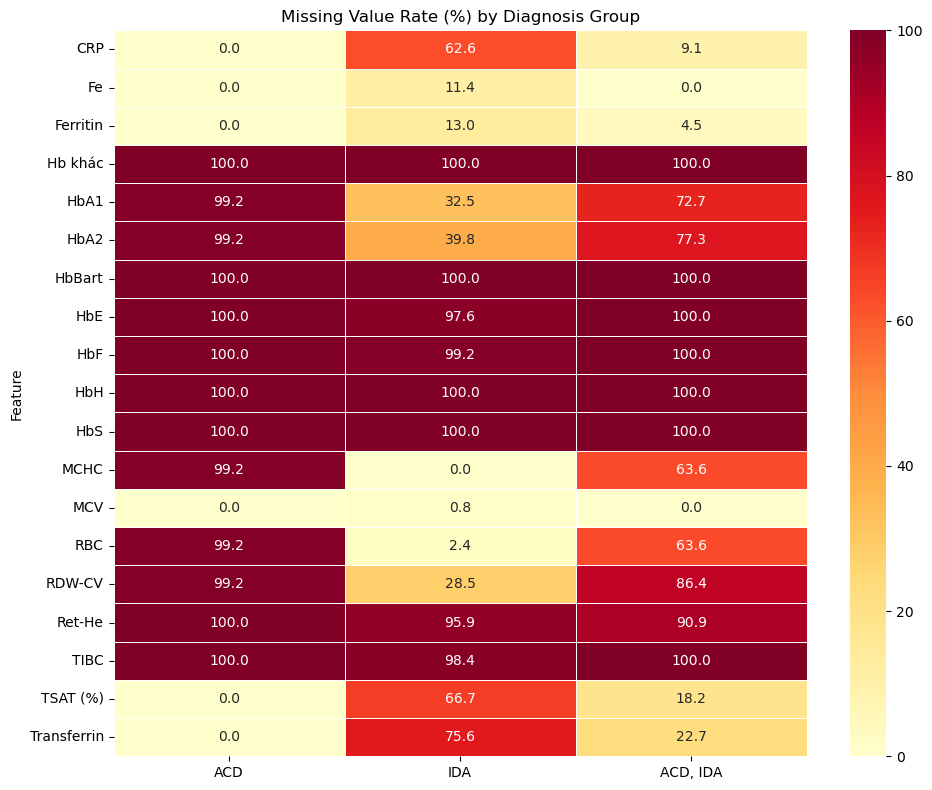

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["ACD", "IDA", "ACD, IDA"]
exclude = labels + ["Giới_nữ"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

missing_by_diag = pd.DataFrame()
for label in labels:
    subset = df[df["Chẩn đoán"] == label][numeric_cols]
    missing_pct = (subset.isnull().sum() / len(subset) * 100).round(1)
    missing_by_diag[label] = missing_pct

missing_by_diag = missing_by_diag[missing_by_diag.max(axis=1) > 0]

plt.figure(figsize=(10, 8))
sns.heatmap(missing_by_diag, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("Missing Value Rate (%) by Diagnosis Group")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("missing_by_diagnosis.png", dpi=300)
plt.show()

### Shapiro-Wilk Normality Test
Test normality of each feature within each diagnosis group. If most groups reject normality (p<0.05), this justifies using non-parametric tests (Kruskal-Wallis) instead of ANOVA.

In [8]:
from scipy.stats import shapiro
import warnings

labels = ["ACD", "IDA", "ACD, IDA"]
exclude = labels + ["Giới_nữ"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

shapiro_results = []

for col in numeric_cols:
    for label in labels:
        vals = df[df["Chẩn đoán"] == label][col].dropna()
        if len(vals) >= 3:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                stat, p = shapiro(vals)
            shapiro_results.append({
                "Feature": col,
                "Group": label,
                "W-statistic": round(stat, 4),
                "p-value": round(p, 6),
                "Normal": "Yes" if p >= 0.05 else "No"
            })

shapiro_df = pd.DataFrame(shapiro_results)

non_normal_count = shapiro_df[shapiro_df["Normal"] == "No"].shape[0]
total_tests = shapiro_df.shape[0]
print(f"{non_normal_count}/{total_tests} tests reject normality (p<0.05)")
print(f"→ Justifies using Kruskal-Wallis (non-parametric) instead of ANOVA\n")

summary = shapiro_df.pivot_table(index="Feature", columns="Group", values="Normal", aggfunc="first")
print(summary)

18/33 tests reject normality (p<0.05)
→ Justifies using Kruskal-Wallis (non-parametric) instead of ANOVA

Group        ACD ACD, IDA  IDA
Feature                       
CRP           No       No   No
Fe           Yes       No   No
Ferritin      No       No   No
Hb            No      Yes  Yes
HbA1         NaN      Yes   No
HbA2         NaN      Yes   No
HbE          NaN      NaN  Yes
MCHC         NaN      Yes   No
MCV           No      Yes   No
RBC          NaN      Yes  Yes
RDW-CV       NaN      Yes  Yes
Ret-He       NaN      NaN   No
TSAT (%)      No       No   No
Transferrin  Yes      Yes  Yes


### Kruskal-Wallis Test
Compare the distribution of each feature across the diagnosis groups

In [9]:
from scipy.stats import kruskal
import warnings

labels = ["ACD", "IDA", "ACD, IDA"]
exclude = labels + ["Giới_nữ"]#+["MCH", "TIBC","Ret-He", "HbF", "HbBart", "HbS", "Hb khác"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

kw_results = []

for col in numeric_cols:
    groups = []
    for label in labels:
        vals = df[df["Chẩn đoán"] == label][col].dropna()
        if len(vals) >= 3:
            groups.append(vals)

    if len(groups) >= 2:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            stat, p = kruskal(*groups)

        if not pd.isna(stat):
            kw_results.append({
                "Feature": col,
                "H-statistic": round(stat, 4),
                "p-value": round(p, 6),
                "Significant": "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            })

kw_df = pd.DataFrame(kw_results).sort_values("p-value")
print(kw_df.to_string(index=False))

sig_features = kw_df[kw_df["Significant"] != ""]["Feature"].tolist()
print(f"\nStatistically significant features (p<0.05): {sig_features}")

    Feature  H-statistic  p-value Significant
        CRP      74.8529 0.000000         ***
   Ferritin     166.5022 0.000000         ***
         Hb      93.2069 0.000000         ***
        MCV      47.9982 0.000000         ***
   TSAT (%)      30.1752 0.000000         ***
Transferrin      70.7976 0.000000         ***
         Fe      12.7339 0.001717          **
       MCHC       1.6726 0.195914            
        RBC       1.1833 0.276686            
       HbA2       1.0480 0.305964            
       HbA1       0.9281 0.335361            
     RDW-CV       0.1429 0.705437            

Statistically significant features (p<0.05): ['CRP', 'Ferritin', 'Hb', 'MCV', 'TSAT (%)', 'Transferrin', 'Fe']


In [10]:
import scikit_posthocs as sp
import warnings

labels = ["ACD", "IDA", "ACD, IDA"]
exclude = labels + ["Giới_nữ"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

sig_features = kw_df[kw_df["Significant"] != ""]["Feature"].tolist()

for col in sig_features:
    melted = []
    for label in labels:
        vals = df[df["Chẩn đoán"] == label][col].dropna()
        for v in vals:
            melted.append({"Group": label, "Value": v})

    melted_df = pd.DataFrame(melted)

    if melted_df.empty or melted_df["Group"].nunique() < 2:
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dunn = sp.posthoc_dunn(melted_df, val_col="Value", group_col="Group", p_adjust="bonferroni")

    sig_pairs = []
    for i in range(len(dunn.index)):
        for j in range(i + 1, len(dunn.columns)):
            g1, g2 = dunn.index[i], dunn.columns[j]
            p = dunn.iloc[i, j]
            if p < 0.05:
                star = "***" if p < 0.001 else "**" if p < 0.01 else "*"
                sig_pairs.append(f"  {g1} vs {g2}: p={p:.6f} {star}")

    if sig_pairs:
        print(f"\n{col}")
        for pair in sig_pairs:
            print(pair)


CRP
  ACD vs IDA: p=0.000000 ***
  ACD, IDA vs IDA: p=0.000000 ***

Ferritin
  ACD vs IDA: p=0.000000 ***
  ACD, IDA vs IDA: p=0.000003 ***

Hb
  ACD vs ACD, IDA: p=0.019135 *
  ACD vs IDA: p=0.000000 ***
  ACD, IDA vs IDA: p=0.034337 *

MCV
  ACD vs IDA: p=0.000000 ***
  ACD, IDA vs IDA: p=0.025784 *

TSAT (%)
  ACD vs IDA: p=0.000000 ***

Transferrin
  ACD vs IDA: p=0.000000 ***
  ACD, IDA vs IDA: p=0.000006 ***

Fe
  ACD vs IDA: p=0.003857 **


### Univariable Distribution

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df_copy= df.copy()

X_y_don= df_copy.drop(columns= ["ACD", "IDA"])


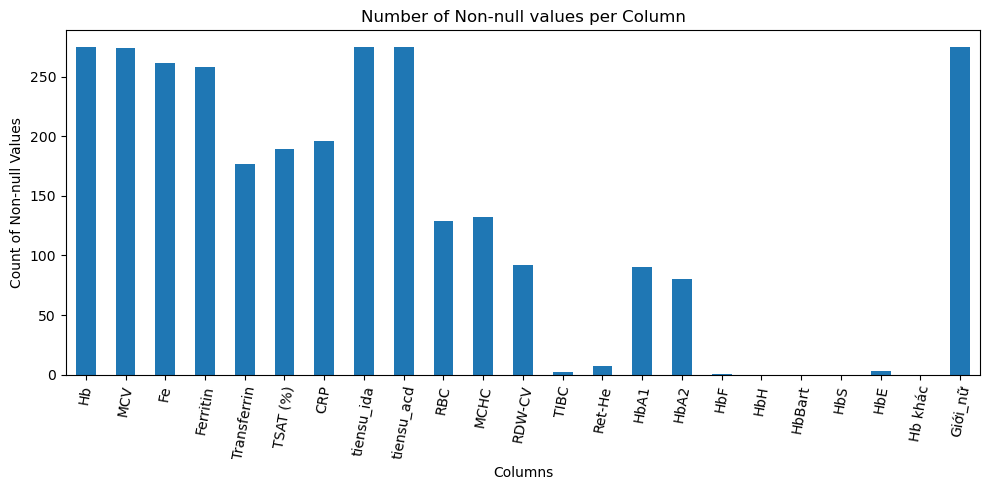

In [13]:
null_X = X_y_don.drop(columns=["Chẩn đoán"])

# Đổi tên cột
#null_X = null_X.rename(columns={
    #"Giới_nữ": "Giới tính"
#})

null_counts = null_X.notnull().sum()

plt.figure(figsize=(10, 5))
null_counts.plot(kind='bar')

plt.xticks(rotation=80)

plt.title('Number of Non-null values per Column')
plt.xlabel('Columns')
plt.ylabel('Count of Non-null Values')

plt.tight_layout()
plt.show()

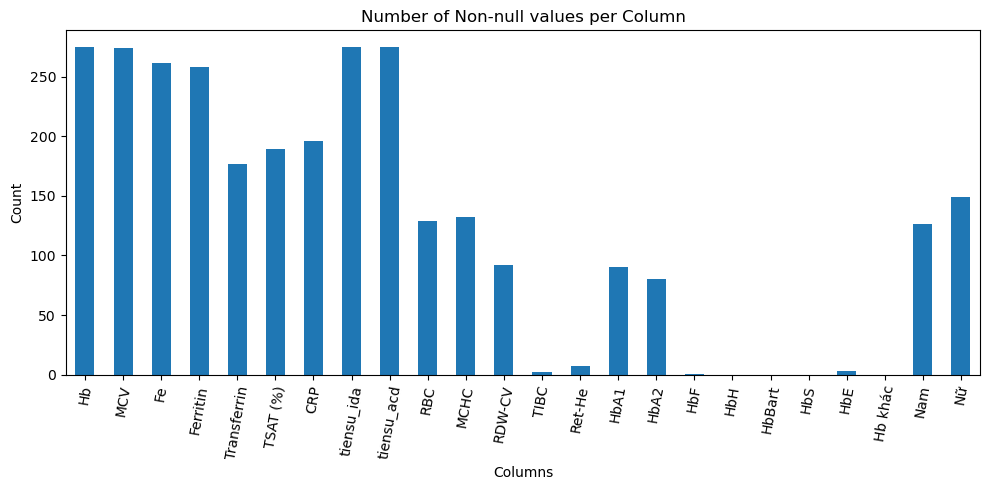

In [14]:
null_X = X_y_don.drop(columns=["Chẩn đoán"])

null_counts = null_X.notnull().sum()

# Đếm số Nam/Nữ
gender_counts = pd.Series({
    "Nam": (X_y_don["Giới_nữ"] == 0).sum(),
    "Nữ": (X_y_don["Giới_nữ"] == 1).sum()
})

# Bỏ cột giới tính cũ
null_counts = null_counts.drop("Giới_nữ")

# Thêm Nam và Nữ vào
null_counts = pd.concat([null_counts, gender_counts])

plt.figure(figsize=(10, 5))
null_counts.plot(kind="bar")

plt.xticks(rotation=80)

plt.title("Number of Non-null values per Column")
plt.xlabel("Columns")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

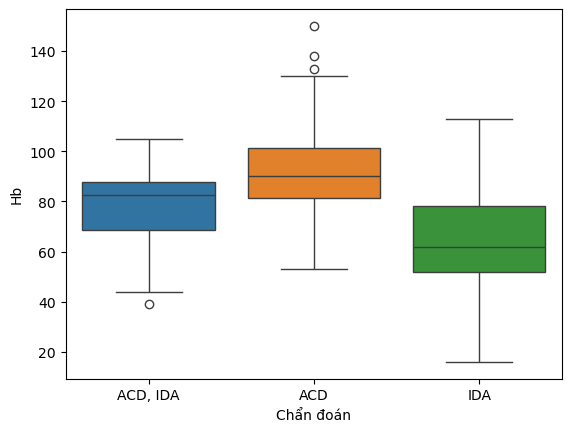

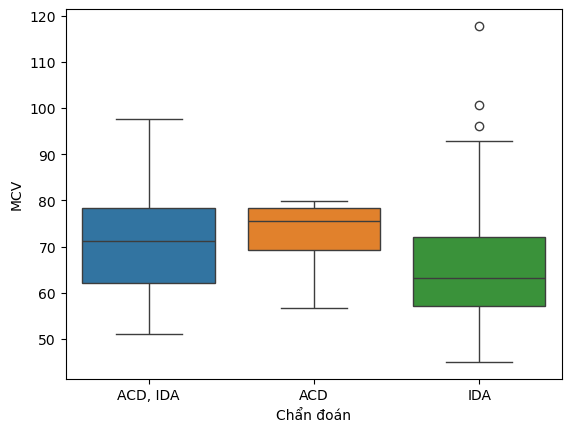

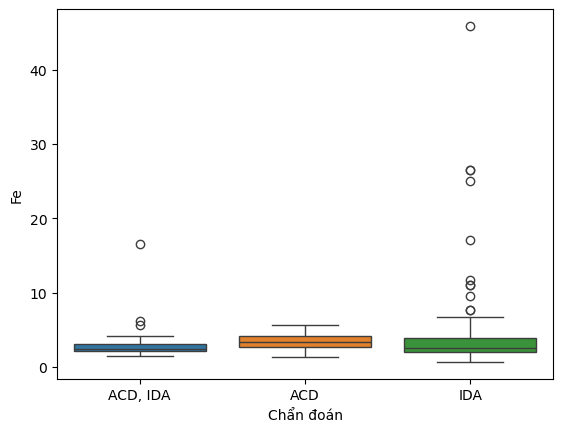

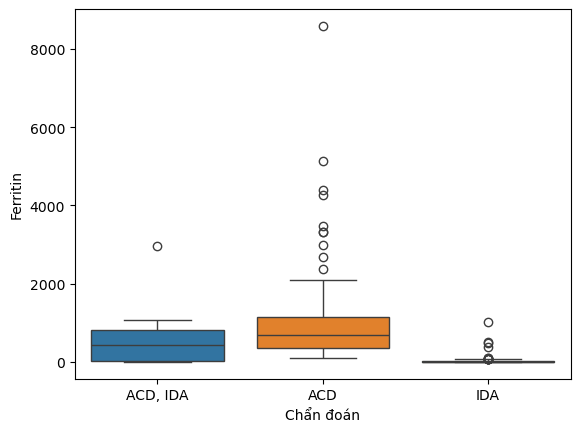

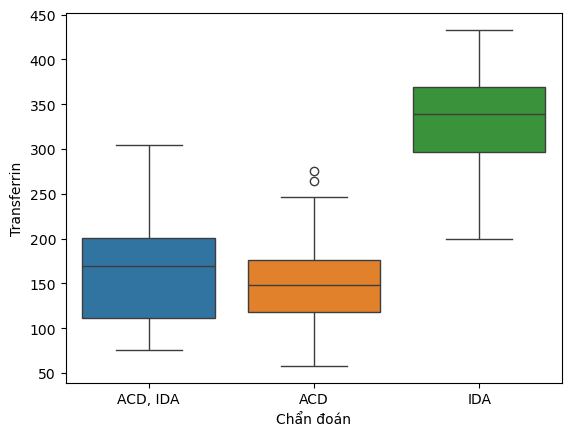

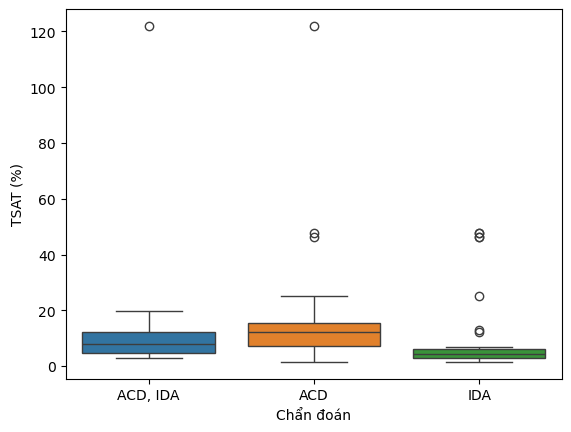

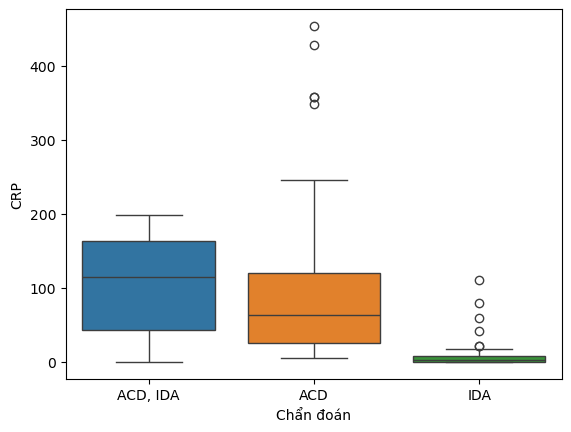

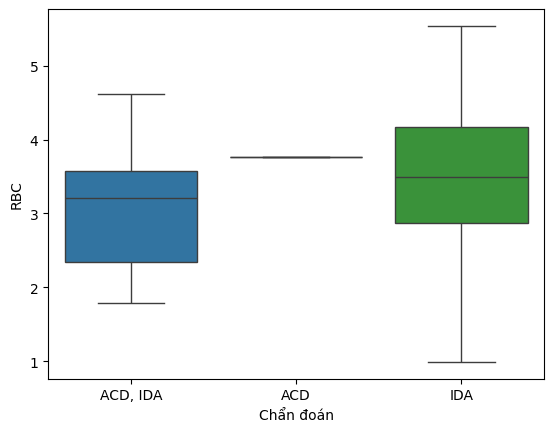

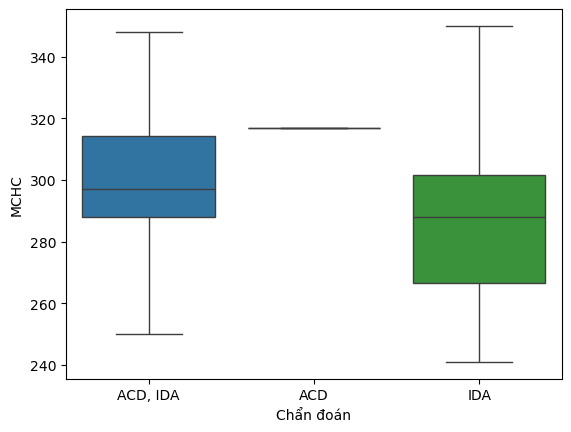

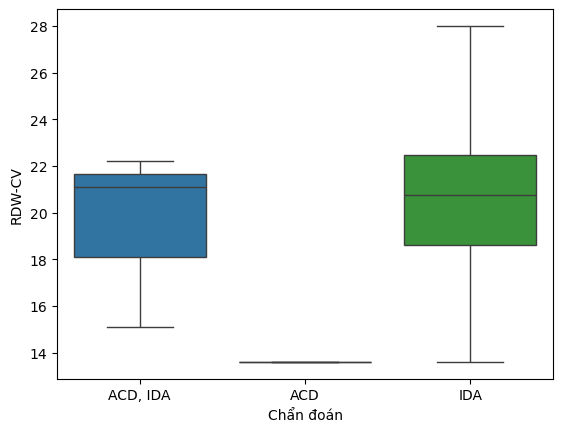

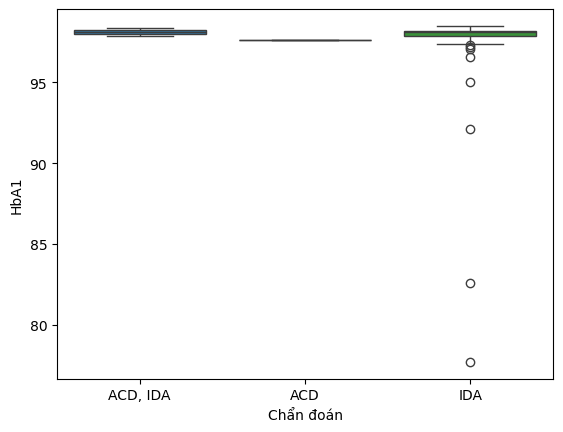

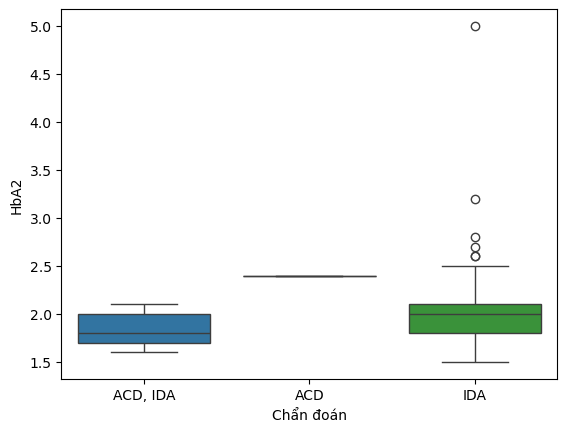

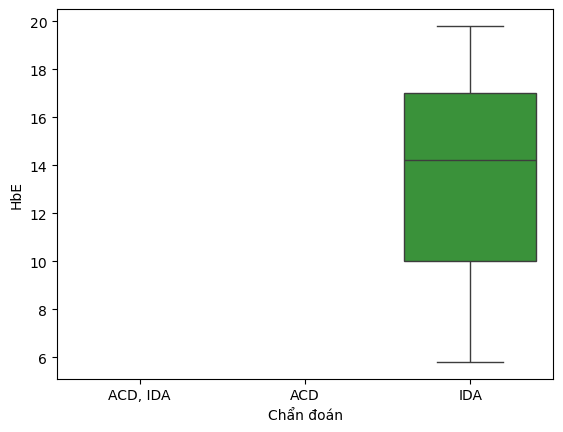

In [17]:
X_y_don_notnull= X_y_don.drop(columns= ["TIBC", "Ret-He", "HbF", "HbH", "HbBart", "HbS", "Hb khác", "tiensu_ida", "tiensu_acd", "Giới_nữ"])

for col_name in X_y_don_notnull.columns:
    if col_name != "Chẩn đoán":
        plt.figure()
        sns.boxplot(
        data=X_y_don_notnull,
        x="Chẩn đoán",
        y=col_name,
        hue="Chẩn đoán",
        legend=False
    )
        # plt.legend(
        # title= f"Distribution of {col_name} by diagnosis",
        # bbox_to_anchor=(1.05, 1),
        # loc='upper left')
        plt.show()

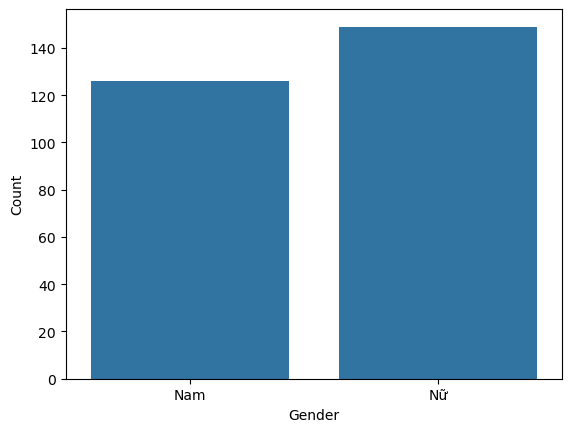

In [18]:
X_y_don_notnull["Giới"] = X_y_don["Giới_nữ"].map({
    False: "Nam",
    True: "Nữ"
})

sns.countplot(data=X_y_don_notnull, x="Giới")

plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

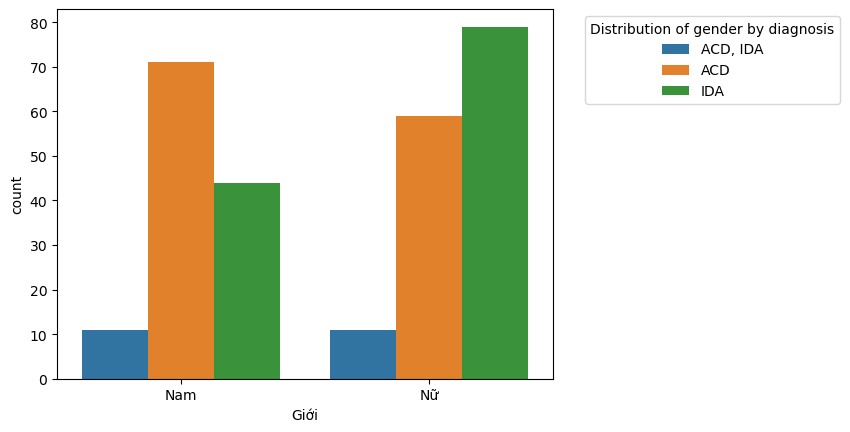

In [19]:
plt.figure()
sns.countplot(data= X_y_don_notnull, x="Giới", hue= "Chẩn đoán")
plt.legend(
    title= "Distribution of gender by diagnosis",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

In [ ]:
# làm cái này với điều kiện no null values

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = X_y_don.drop("Chẩn đoán", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=X_y_don["Chẩn đoán"])

In [ ]:
from sklearn.manifold import TSNE
# làm cái này với điều kiện no null values

X = df.drop("Chẩn đoán", axis=1)
X_embedded = TSNE(n_components=2).fit_transform(X)

plt.figure()
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=df["Chẩn đoán"])
plt.legend(
    title="Chẩn đoán",
    bbox_to_anchor=(1.05, 1),  # đẩy sang phải
    loc='upper left'
)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# làm cái này với điều kiện no null values

X = df.drop("Chẩn đoán", axis=1)
X_embedded = TSNE(n_components=2).fit_transform(X)
score = silhouette_score(X_embedded, df["Chẩn đoán"])
print(score)

In [ ]:
plt.figure()
# làm cái này với điều kiện no null values

X = df.drop("Chẩn đoán", axis=1)
X_embedded = TSNE(n_components=2).fit_transform(X)

ax = sns.kdeplot(
    x=X_embedded[:,0],
    y=X_embedded[:,1],
    hue=df["Chẩn đoán"]
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# làm cái này với điều kiện no null values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=clusters)

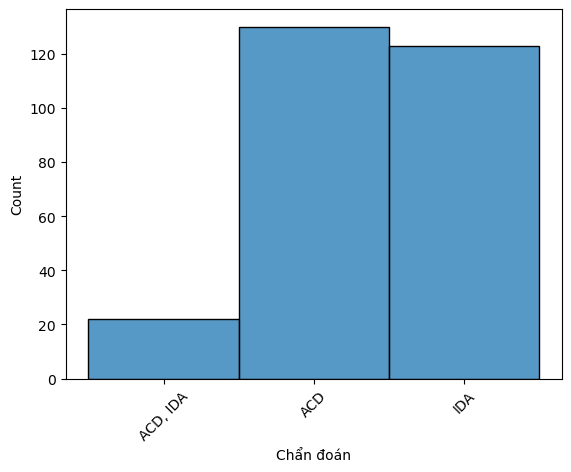

In [20]:
sns.histplot(df["Chẩn đoán"])
plt.xticks(rotation=45)
plt.show()

In [ ]:
y = df[["ACD", "IDA"]]

counts = y.value_counts()

print(counts)

In [ ]:
import pandas as pd

# Các nhãn
labels = ["ACD", "IDA", "ACD, IDA"]

# Ma trận đồng xuất hiện
co_matrix = pd.DataFrame(
    0,
    index=labels,
    columns=labels
)

# Đếm số lần xuất hiện cùng nhau
for _, row in y.iterrows():

    active_labels = row[row == 1].index.tolist()

    for l1 in active_labels:
        for l2 in active_labels:
            co_matrix.loc[l1, l2] += 1

print(co_matrix)